# Customer Segmentation using RFM Analysis and K-Means Clustering

## Project Overview
This project analyzes customer purchasing behavior using an online retail dataset.
Customers are segmented using RFM (Recency, Frequency, Monetary) analysis and the
K-Means clustering algorithm to identify meaningful customer groups.

The objective is to help businesses understand different types of customers
and develop targeted marketing strategies.

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

## DATA LOADING 

In [53]:
df = pd.read_excel(
    "../data/online_retail_II.xlsx",
    sheet_name="Year 2010-2011"
)

In [54]:
df.to_csv("../data/online_retail.csv", index=False)

In [55]:
df.to_csv("../data/online_retail_cleaned.csv", index=False)

## DATA CLEANING 

In [56]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [57]:
df.shape

(541910, 8)

In [58]:
df.columns 

Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

In [59]:
df.isna().sum()

Invoice             0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
Price               0
Customer ID    135080
Country             0
dtype: int64

In [60]:
df = df.dropna(subset=['Customer ID'])

In [61]:
df.duplicated().sum()

np.int64(5225)

In [62]:
df = df.drop_duplicates()

## EXPLORATORY DATA ANALYSIS

In [63]:
df['Customer ID'].unique()
df['Customer ID'].nunique()


4372

In [64]:
df['Country'].value_counts().head(10)

Country
United Kingdom    356728
Germany             9480
France              8476
EIRE                7475
Spain               2528
Netherlands         2371
Belgium             2069
Switzerland         1877
Portugal            1471
Australia           1258
Name: count, dtype: int64

In [65]:
(df['Quantity']<0).sum()

np.int64(8872)

In [66]:
df = df[df['Quantity'] > 0]

In [67]:
df['Invoice'].astype(str).str.startswith('C').sum()

np.int64(0)

In [68]:
df['TotalPrice'] = df['Quantity'] * df['Price']
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


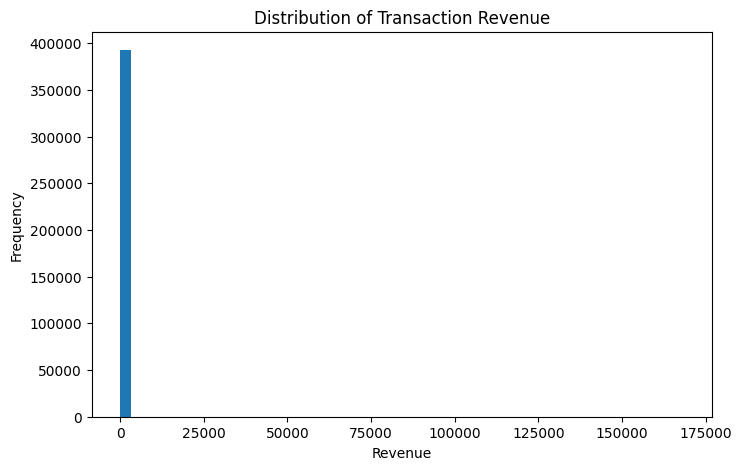

In [69]:
plt.figure(figsize=(8,5))
plt.hist(df['TotalPrice'], bins=50)
plt.title("Distribution of Transaction Revenue")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()

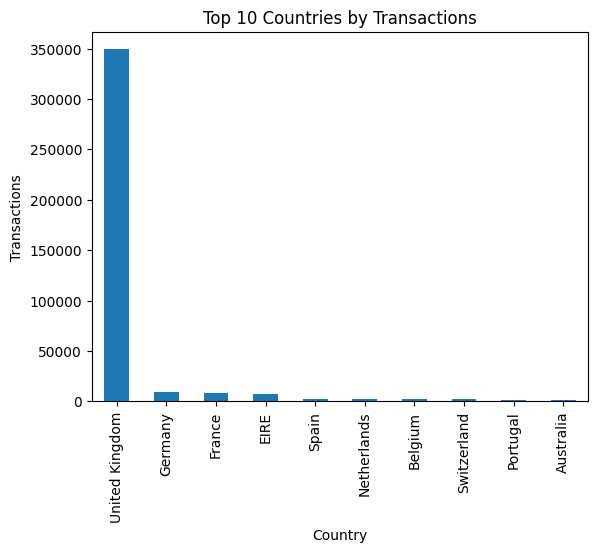

In [70]:
df['Country'].value_counts().head(10).plot(kind='bar')

plt.title("Top 10 Countries by Transactions")
plt.xlabel("Country")
plt.ylabel("Transactions")
plt.show()

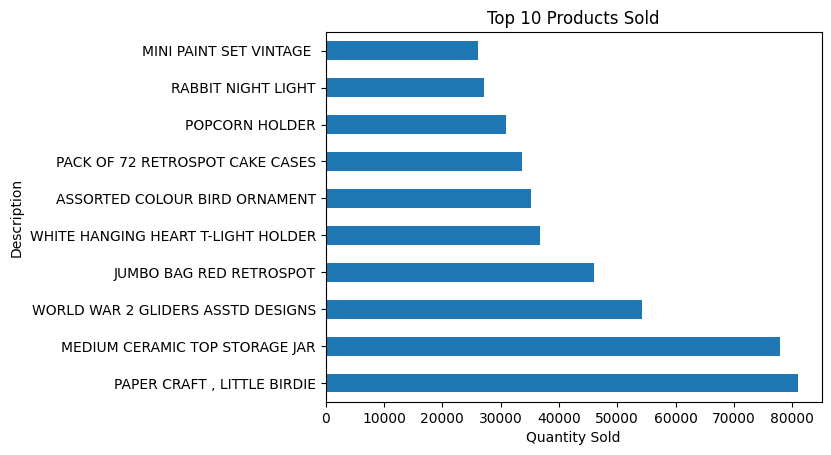

In [71]:
top_products = df.groupby('Description')['Quantity'].sum().sort_values(ascending=False).head(10)

top_products.plot(kind='barh')

plt.title("Top 10 Products Sold")
plt.xlabel("Quantity Sold")
plt.show()

In [72]:
df['Customer ID'].value_counts().head(10)

Customer ID
17841.0    7676
14911.0    5672
14096.0    5111
12748.0    4413
14606.0    2677
15311.0    2366
14646.0    2080
13089.0    1814
13263.0    1667
14298.0    1637
Name: count, dtype: int64

## RFM ANALYSIS

In [73]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [74]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

In [75]:
recency = df.groupby('Customer ID')['InvoiceDate'].max().reset_index()

recency['Recency'] = (snapshot_date - recency['InvoiceDate']).dt.days
recency = recency[['Customer ID','Recency']]

In [76]:
frequency = df.groupby('Customer ID')['Invoice'].nunique().reset_index()

frequency.columns = ['Customer ID','Frequency']

In [77]:
df['TotalPrice'] = df['Quantity'] * df['Price']
monetary = df.groupby('Customer ID')['TotalPrice'].sum().reset_index()
monetary.columns = ['Customer ID','Monetary']

In [78]:
rfm = recency.merge(frequency, on='Customer ID')

rfm = rfm.merge(monetary, on='Customer ID')

In [79]:
rfm.shape

(4339, 4)

In [80]:
rfm.describe()

,Customer ID,Recency,Frequency,Monetary
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,15299.936852,92.518322,4.271952,2048.220072
std,1721.889758,100.009747,7.705493,8984.247808
min,12346.000000,1.000000,1.000000,0.000000
25%,13812.500000,18.000000,1.000000,306.455000
50%,15299.000000,51.000000,2.000000,668.560000
75%,16778.500000,142.000000,5.000000,1660.315000
max,18287.000000,374.000000,210.000000,280206.020000


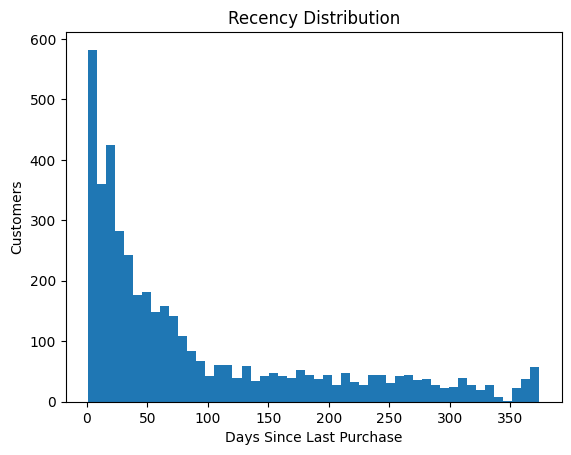

In [81]:
plt.hist(rfm['Recency'], bins=50)
plt.title("Recency Distribution")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Customers")
plt.show()

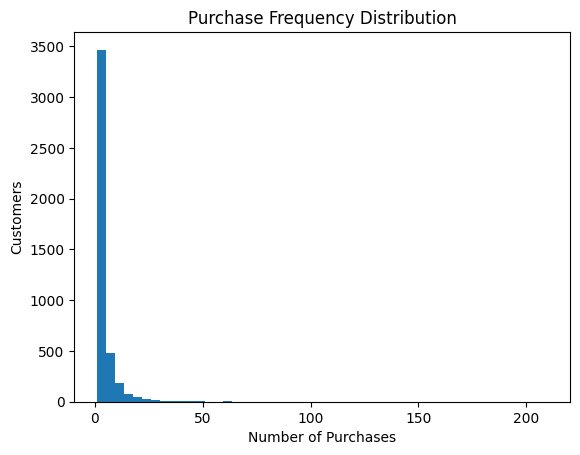

In [82]:
plt.hist(rfm['Frequency'], bins=50)
plt.title("Purchase Frequency Distribution")
plt.xlabel("Number of Purchases")
plt.ylabel("Customers")
plt.show()

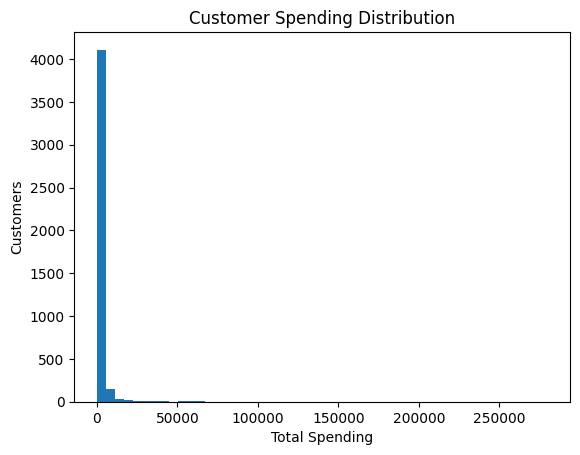

In [83]:
plt.hist(rfm['Monetary'], bins=50)
plt.title("Customer Spending Distribution")
plt.xlabel("Total Spending")
plt.ylabel("Customers")
plt.show()

In [84]:
rfm[['Recency','Frequency','Monetary']].corr()

,Recency,Frequency,Monetary
Recency,1.000000,-0.260253,-0.121781
Frequency,-0.260253,1.000000,0.553223
Monetary,-0.121781,0.553223,1.000000


In [85]:
rfm_features = rfm[['Recency','Frequency','Monetary']]


## SCALING 

In [86]:
rfm_scaled = (rfm_features - rfm_features.mean()) / rfm_features.std()
rfm_scaled.describe()

,Recency,Frequency,Monetary
count,4.339000e+03,4339.000000,4.339000e+03
mean,7.614712e-17,0.000000,-4.585203e-17
std,1.000000e+00,1.000000,1.000000e+00
min,-9.150940e-01,-0.424626,-2.279790e-01
25%,-7.451106e-01,-0.424626,-1.938688e-01
50%,-4.151428e-01,-0.294848,-1.535643e-01
75%,4.947686e-01,0.094484,-4.317613e-02
max,2.814542e+00,26.698883,3.096061e+01


## DETERMINING OPTIMAL CLUSTERS(ELBOW METHOD)

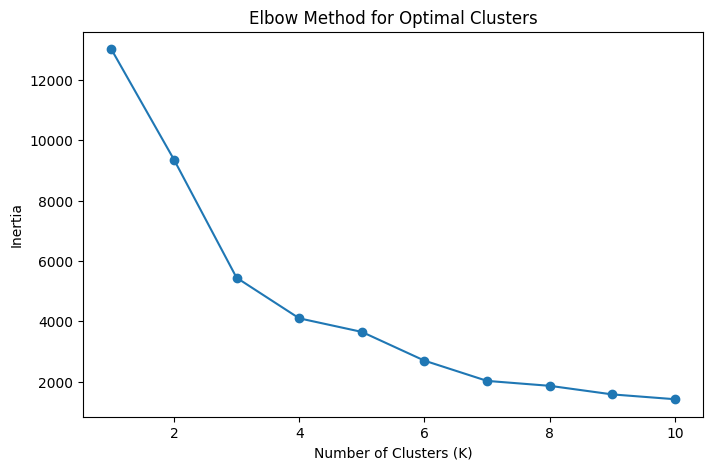

In [87]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(rfm_scaled)
    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K_range, inertia, marker='o')

plt.title("Elbow Method for Optimal Clusters")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")

plt.show()

## K-MEANS CLUSTERING 

In [88]:

kmeans = KMeans(n_clusters=4, random_state=42)

In [89]:
kmeans.fit(rfm_scaled)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [90]:
rfm['Cluster'] = kmeans.labels_

In [91]:
rfm.head()

,Customer ID,Recency,Frequency,Monetary,Cluster
0,12346.0,326,1,77183.60,0
1,12347.0,2,7,4310.00,3
2,12348.0,75,4,1797.24,3
3,12349.0,19,1,1757.55,3
4,12350.0,310,1,334.40,1


In [92]:
rfm['Cluster'].value_counts()

Cluster
3    3053
1    1062
0     211
2      13
Name: count, dtype: int64

## PCA 

In [93]:
pca = PCA(n_components=2)

In [94]:
pca_features = pca.fit_transform(rfm_scaled)

In [95]:
pca_df = pd.DataFrame(pca_features, columns=['PC1', 'PC2'])
pca_df['Cluster'] = rfm['Cluster']

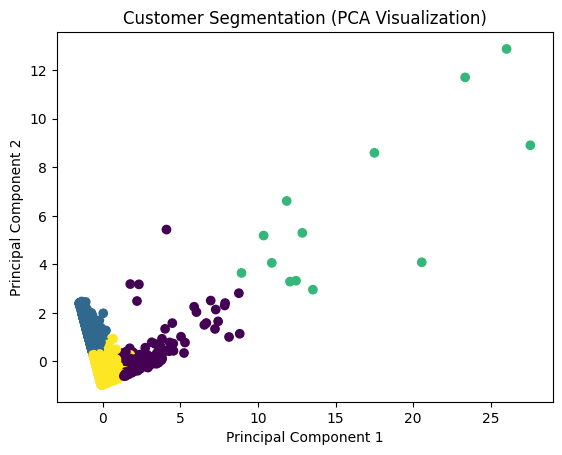

In [96]:
plt.scatter(
    pca_df['PC1'],
    pca_df['PC2'],
    c=pca_df['Cluster'],
)

plt.title("Customer Segmentation (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

In [97]:
cluster_summary = rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,15.672986,22.047393,12435.086682
1,248.564030,1.551789,476.330547
2,7.384615,82.692308,127187.959231
3,43.910580,3.655748,1344.289909


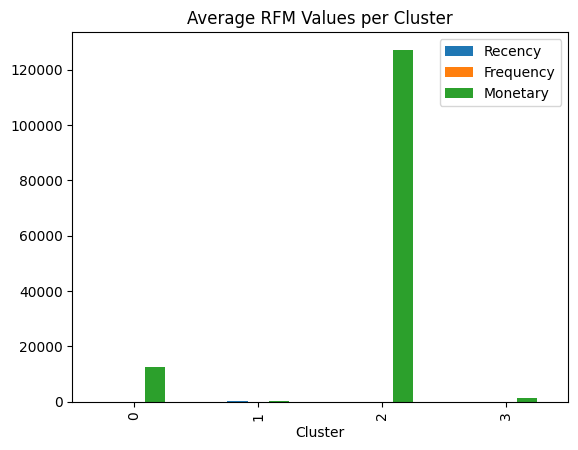

In [98]:
cluster_summary.plot(kind='bar')
plt.title("Average RFM Values per Cluster")
plt.show()

## Customer Segmentation (RFM Analysis)

RFM analysis is a customer segmentation technique that evaluates customer behavior
based on three key metrics:

- **Recency** – How recently a customer made a purchase
- **Frequency** – How often a customer makes purchases
- **Monetary Value** – How much money a customer spends

These features help identify different types of customers and enable businesses
to develop targeted marketing strategies.

### Cluster 2 – VIP Customers
Customers in this segment have very low recency, extremely high purchase frequency,
and the highest monetary value. This indicates highly loyal customers who purchase
frequently and contribute significantly to revenue.

Business Strategy:
- Offer loyalty rewards
- Provide exclusive offers
- Maintain strong customer relationships

### Cluster 0 – Loyal Customers
These customers purchase regularly and generate significant revenue.
They are active customers with moderate recency and high purchase frequency.

Business Strategy:
- Provide loyalty discounts
- Recommend related products
- Encourage repeat purchases

### Cluster 3 – Regular Customers
These customers purchase occasionally and have moderate spending levels.
They are somewhat engaged but not highly loyal.

Business Strategy:
- Offer targeted promotions
- Send personalized product recommendations
- Encourage more frequent purchases

### Cluster 1 – At-Risk Customers
Customers in this cluster have very high recency and very low purchase frequency,
indicating they have not purchased for a long time and may churn.

Business Strategy:
- Re-engagement campaigns
- Discount offers
- Email reminders

### Business Insights

The clustering analysis identified four distinct customer segments.
VIP and loyal customers contribute the majority of revenue and should be prioritized
for retention strategies. At-risk customers require re-engagement campaigns to
encourage them to return. Regular customers can be converted into loyal customers
through targeted promotions and personalized recommendations.

## Conclusion

This project applied RFM analysis and K-Means clustering to segment customers
based on their purchasing behavior. Four distinct customer groups were identified,
including VIP customers, loyal customers, regular customers, and at-risk customers.

These segments provide valuable insights for businesses to design targeted marketing
strategies, improve customer retention, and increase revenue.

Future improvements could include:
- testing additional clustering algorithms such as hierarchical clustering
- incorporating customer demographic data
- deploying the model in a real-time marketing system